<a href="https://colab.research.google.com/github/SHAHAB-UDDIN54/codealpha_tasks/blob/main/Task1_Credit_Scoring_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Task 1: Credit Scoring Model
### CodeAlpha Machine Learning Internship
**Objective:** Predict an individual's creditworthiness using past financial data.  
**Approach:** Classification algorithms — Logistic Regression, Decision Trees, Random Forest  
**Metrics:** Precision, Recall, F1-Score, ROC-AUC


In [1]:
# ─── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ─── Generate Realistic Credit Dataset ──────────────────────────────────────
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'age':              np.random.randint(21, 70, n),
    'income':           np.random.normal(55000, 20000, n).clip(15000, 200000).astype(int),
    'loan_amount':      np.random.normal(12000, 6000, n).clip(1000, 50000).astype(int),
    'loan_tenure':      np.random.randint(12, 84, n),
    'credit_history':   np.random.randint(0, 2, n),       # 0=bad, 1=good
    'num_late_payments':np.random.randint(0, 10, n),
    'debt_to_income':   np.random.uniform(0.05, 0.65, n).round(3),
    'num_credit_lines': np.random.randint(1, 15, n),
    'employment_years': np.random.randint(0, 30, n),
})

# Target: creditworthy (1) or not (0)
score = (
    (df['income'] / 50000) * 0.3 +
    df['credit_history'] * 0.25 -
    df['num_late_payments'] * 0.12 -
    df['debt_to_income'] * 0.25 +
    (df['employment_years'] / 20) * 0.1
)
df['creditworthy'] = (score + np.random.normal(0, 0.3, n) > 0.5).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['creditworthy'].value_counts()}")
print(f"\nDefault rate: {(df['creditworthy'] == 0).mean():.1%}")
df.head()


Dataset shape: (1000, 10)

Class distribution:
creditworthy
0    885
1    115
Name: count, dtype: int64

Default rate: 88.5%


,age,income,loan_amount,loan_tenure,credit_history,num_late_payments,debt_to_income,num_credit_lines,employment_years,creditworthy
0,59,58479,6572,33,0,5,0.317,3,11,0
1,49,73157,10181,44,1,7,0.630,14,19,0
2,35,54824,6734,41,1,2,0.393,13,15,0
3,63,64028,16694,43,1,7,0.568,7,13,0
4,28,71317,8504,53,0,1,0.134,5,15,0


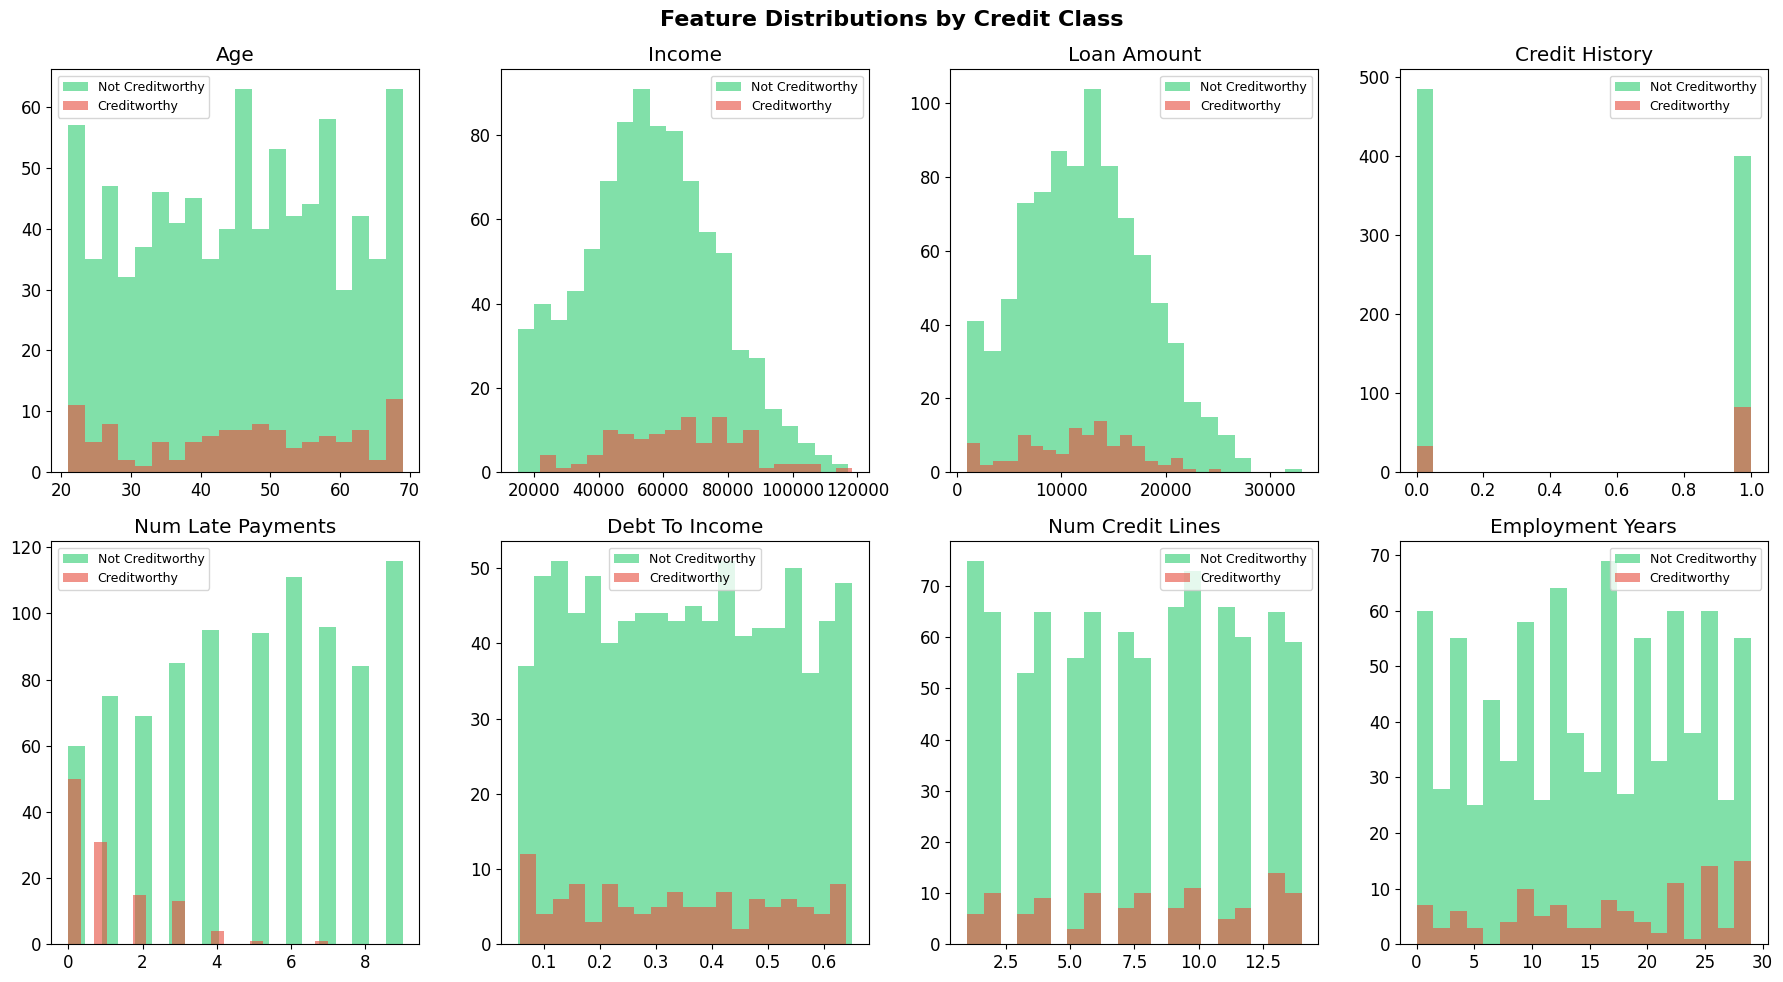

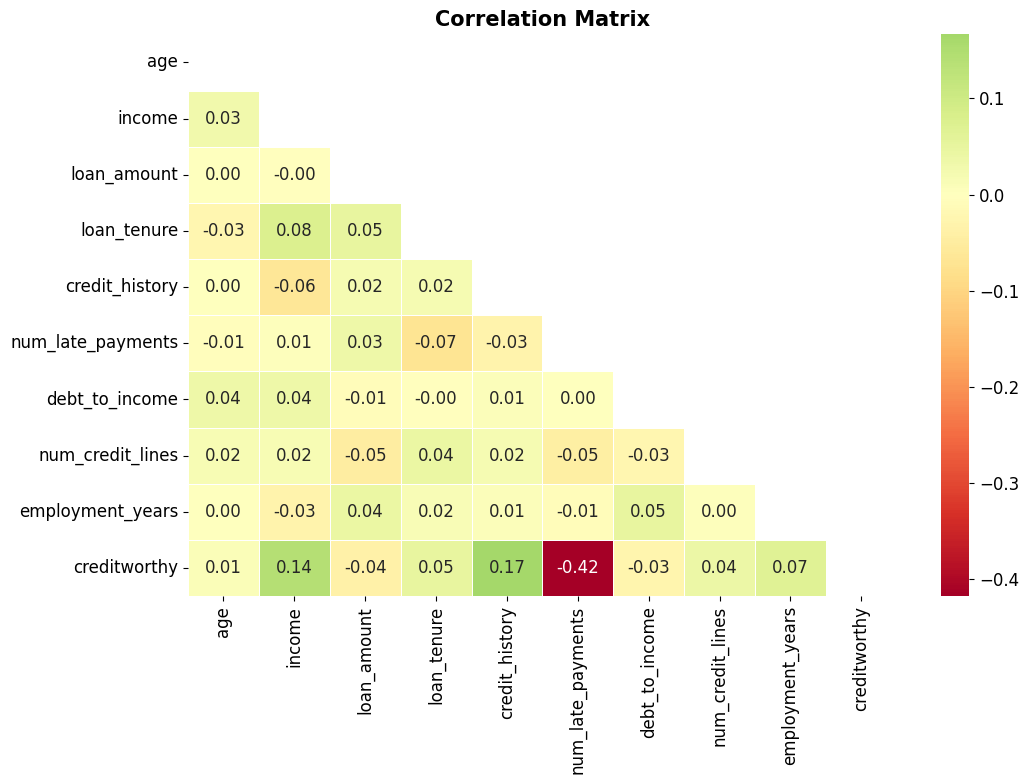

In [3]:
# ─── Exploratory Data Analysis ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
features = ['age', 'income', 'loan_amount', 'credit_history',
            'num_late_payments', 'debt_to_income', 'num_credit_lines', 'employment_years']
colors = ['#2ecc71', '#e74c3c']
labels = ['Not Creditworthy', 'Creditworthy']

for i, col in enumerate(features):
    for cls, color, label in zip([0, 1], colors, labels):
        subset = df[df['creditworthy'] == cls][col]
        axes[i].hist(subset, alpha=0.6, color=color, label=label, bins=20)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Credit Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


In [4]:
# ─── Feature Engineering & Preprocessing ────────────────────────────────────
# New engineered features
df['loan_to_income']     = (df['loan_amount'] / df['income']).round(4)
df['monthly_obligation'] = (df['loan_amount'] / df['loan_tenure']).round(2)
df['payment_discipline'] = (10 - df['num_late_payments']) / 10

X = df.drop('creditworthy', axis=1)
y = df['creditworthy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Features used: {list(X.columns)}")


Train size: 800 | Test size: 200
Features used: ['age', 'income', 'loan_amount', 'loan_tenure', 'credit_history', 'num_late_payments', 'debt_to_income', 'num_credit_lines', 'employment_years', 'loan_to_income', 'monthly_obligation', 'payment_discipline']


In [5]:
# ─── Train Multiple Models ───────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=150, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=150, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    cv_sc   = cross_val_score(model, X_train_sc, y_train, cv=5, scoring='roc_auc').mean()
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'roc_auc': roc_auc_score(y_test, y_proba), 'cv_auc': cv_sc
    }
    print(f"  {name:25s} | Test AUC: {roc_auc_score(y_test, y_proba):.4f} | CV AUC: {cv_sc:.4f}")


  Logistic Regression       | Test AUC: 0.9091 | CV AUC: 0.9085
  Decision Tree             | Test AUC: 0.8355 | CV AUC: 0.7448
  Random Forest             | Test AUC: 0.8973 | CV AUC: 0.8755
  Gradient Boosting         | Test AUC: 0.9042 | CV AUC: 0.8572


🏆 Best Model: Logistic Regression

                  precision    recall  f1-score   support

Not Creditworthy       0.91      0.97      0.94       177
    Creditworthy       0.55      0.26      0.35        23

        accuracy                           0.89       200
       macro avg       0.73      0.62      0.65       200
    weighted avg       0.87      0.89      0.87       200



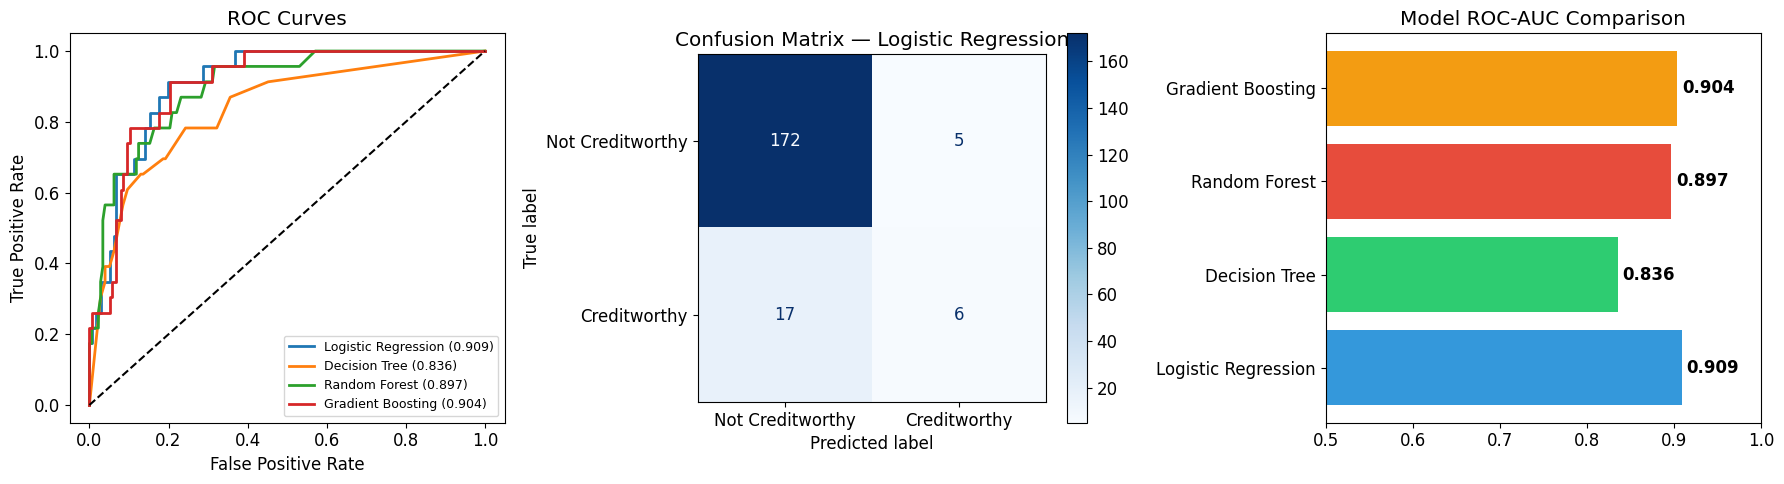

In [6]:
# ─── Detailed Evaluation ─────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best      = results[best_name]

print(f"🏆 Best Model: {best_name}\n")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Not Creditworthy', 'Creditworthy']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} ({res['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves'); axes[0].legend(fontsize=9)

# 2) Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, best['y_pred'],
    display_labels=['Not Creditworthy', 'Creditworthy'],
    cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix — {best_name}')

# 3) AUC Comparison
names = list(results.keys())
aucs  = [results[n]['roc_auc'] for n in names]
bars  = axes[2].barh(names, aucs, color=['#3498db','#2ecc71','#e74c3c','#f39c12'])
axes[2].set_xlim(0.5, 1.0)
axes[2].set_title('Model ROC-AUC Comparison')
for bar, auc in zip(bars, aucs):
    axes[2].text(auc + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{auc:.3f}', va='center', fontweight='bold')

plt.tight_layout(); plt.show()


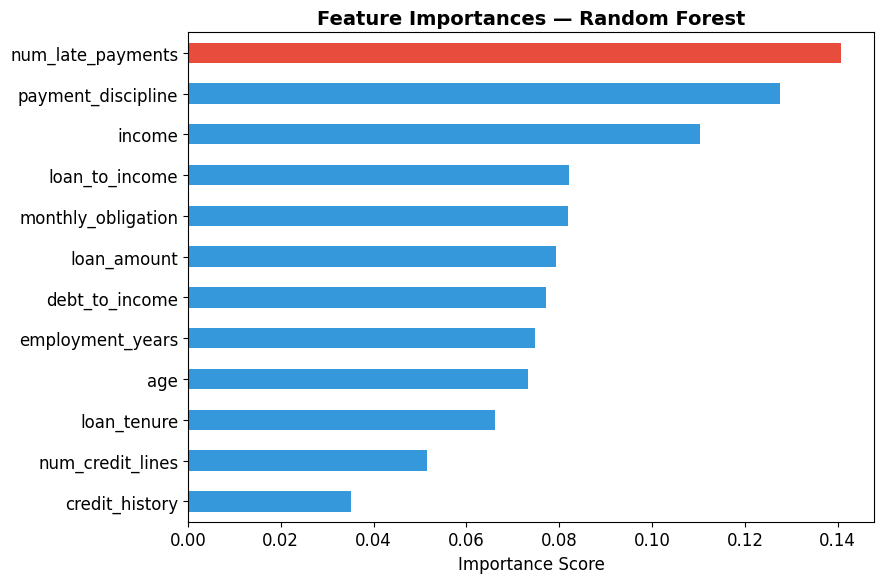


📊 Summary Table:
              Model  ROC-AUC  CV-AUC
Logistic Regression   0.9091  0.9085
  Gradient Boosting   0.9042  0.8572
      Random Forest   0.8973  0.8755
      Decision Tree   0.8355  0.7448


In [7]:
# ─── Feature Importance (Random Forest) ─────────────────────────────────────
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(9, 6))
colors_ = ['#e74c3c' if i == importances.idxmax() else '#3498db'
           for i in importances.index]
importances.plot(kind='barh', color=colors_)
plt.title('Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print("\n📊 Summary Table:")
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [round(results[n]['roc_auc'], 4) for n in results],
    'CV-AUC':  [round(results[n]['cv_auc'],  4) for n in results]
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))
